In [2]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn

from astropy.io import fits

%matplotlib inline

Defining the path for the fits file 

In [3]:
path_249 = "../FITS_data/G_249-49.fits"

Opening the fits file and saving it in a variable called data_249 and printing out its summary

In [4]:
with fits.open(path_249) as data_249:
    data_249.info()

print(data_249)

Filename: ../FITS_data/G_249-49.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     107   (15011,)   float32   
  1  c0002210065    1 ImageHDU       143   (3066, 1, 4)   float32   
  2  c0010250056    1 ImageHDU       143   (3061, 1, 4)   float32   
  3  c0101120035    1 ImageHDU       143   (3062, 1, 4)   float32   
  4  c9512180028    1 ImageHDU       143   (3060, 1, 4)   float32   
  5  c9612200043    1 ImageHDU       143   (3066, 1, 4)   float32   
  6  a0002210065    1 ImageHDU       143   (3066, 1, 4)   float32   
  7  a0010250056    1 ImageHDU       143   (3061, 1, 4)   float32   
  8  a0101120035    1 ImageHDU       143   (3062, 1, 4)   float32   
  9  a9512180028    1 ImageHDU       143   (3060, 1, 4)   float32   
 10  a9612200043    1 ImageHDU       143   (3066, 1, 4)   float32   
[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7e34a0d00140>, <astropy.io.fits.hdu.image.ImageHDU object at 0x7e34a08d2300>, <astropy.io.fits.h

In [5]:
type(data_249)

astropy.io.fits.hdu.hdulist.HDUList

Accessing the primary HDU 

In [8]:
data_249[0]

In [15]:
print(data_249[0].header)   # for the list of headers for the primary HDU
print(data_249[0].shape)  # shape of the array of the primary HDU 


SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel                                 NAXIS   =                    1 / Number of axes                                 NAXIS1  =                15011 / Axis length                                    EXTEND  =                    T / File may contain extensions                    ORIGIN  = 'NOAO-IRAF FITS Image Kernel December 2001' / FITS file originator    DATE    = '2004-02-10T22:46:16' / Date FITS file was generated                  IRAF-TLM= '22:46:16 (10/02/2004)' / Time of last modification                   OBJECT  = 'G_249-49'           / Name of the object observed                    OBSERVAT= 'KPNO              '  /  observatory                                  TELESCOP= 'kpcdf             '  /  telescope name                               DETECTOR= 'f3kb              '  /  detector name                                APERTURE= '200microns        '  /  apert

In [17]:
len(data_249[0].header)    # cards, or total number of headers 

107

Printing out the data array and its length for the primary HDU:

In [22]:
with fits.open(path_249) as file_249:
    print(file_249[0].data)
    print(len(file_249[0].data))

[5.5233443e-01 5.2115417e-01 5.1035464e-01 ... 9.9999997e-05 9.9999997e-05
 9.9999997e-05]
15011


#### Examining the extension HDUs

In [24]:
with fits.open(path_249) as data_249:
    print(data_249[1].header)
    print(data_249[1].data)

XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -32 / Bits per pixel                                 NAXIS   =                    3 / Number of axes                                 NAXIS1  =                 3066 / Axis length                                    NAXIS2  =                    1 / Axis length                                    NAXIS3  =                    4 / Axis length                                    PCOUNT  =                    0 / No 'random' parameters                         GCOUNT  =                    1 / Only one group                                 ORIGIN  = 'NOAO-IRAF FITS Image Kernel December 2001' / FITS file originator    EXTNAME = 'c0002210065'        / Extension name                                 INHERIT =                    F / Inherits global header                         DATE    = '2004-02-10T22:46:16' / Date FITS file was generated                  IRAF-TLM= '22:46:16 (10/02/2004)' / Time

Examining each axis of the 1st extension HDU: 

In [31]:
with fits.open(path_249) as data_249:
    print(f"y axis : {len(data_249[1].data[0])}")     # y axis
    print(f"z axis : {len(data_249[1].data)}")        # z axis
    print(f"x axis : {len(data_249[1].data[0,0])}")   # x axis

y axis : 1
z axis : 4
x axis : 3066


These are the number of data points in float format on each axis of the 3 - Dimensional space of this HDU 

#### Checking for any Flux metadata in the header of the first extension ImageHDU

In [42]:
with fits.open(path_249) as data_249:
    hdr = data_249[1].header
    for key in hdr:
        if "flux" in key.lower():
            print(key)


In [ ]:
with fits.open(path_249) as data_249:
    hdr = data_249[1].header
    for key in hdr:
        print(key)

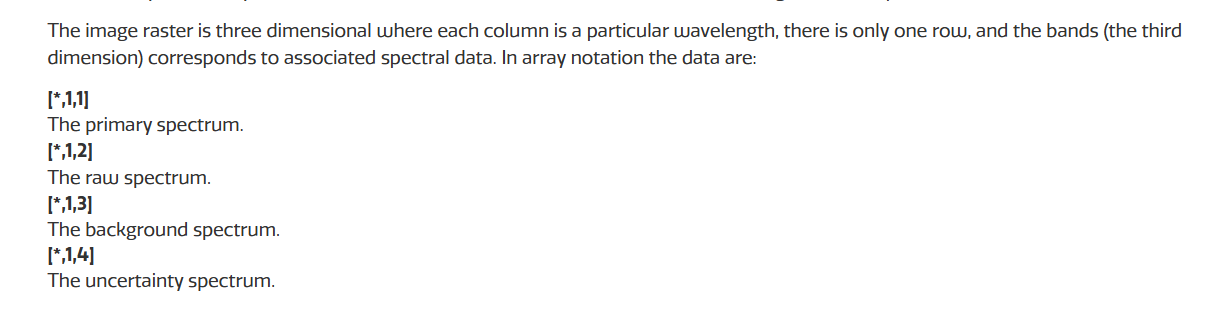

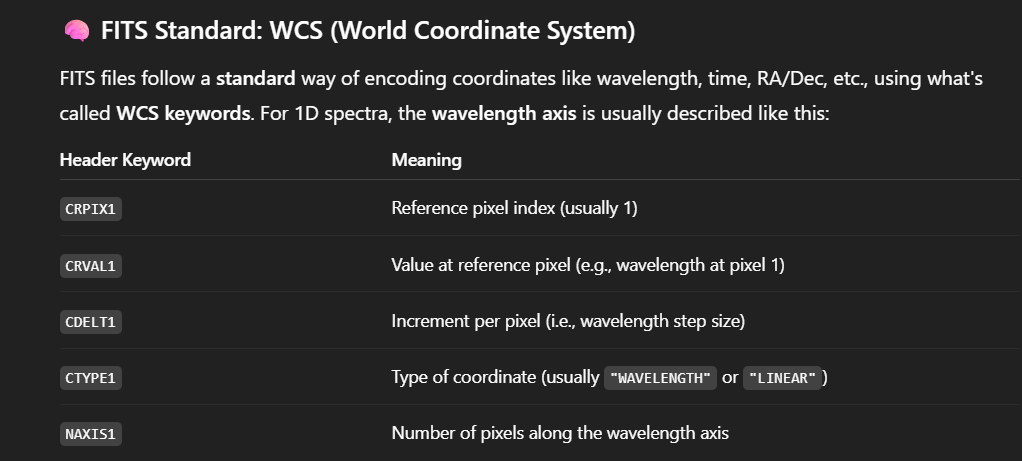

In [52]:
with fits.open(path_249) as data_249:
    hdr = data_249[0].header
    primary_data = data_249[0].data
    print(hdr["CRVAL1"])
    print(hdr["CDELT1"])
    print(primary_data)

3465.0
0.4
[5.5233443e-01 5.2115417e-01 5.1035464e-01 ... 9.9999997e-05 9.9999997e-05
 9.9999997e-05]


Defining the Flux and wavelengths and plotting the flux vs wavelength plot

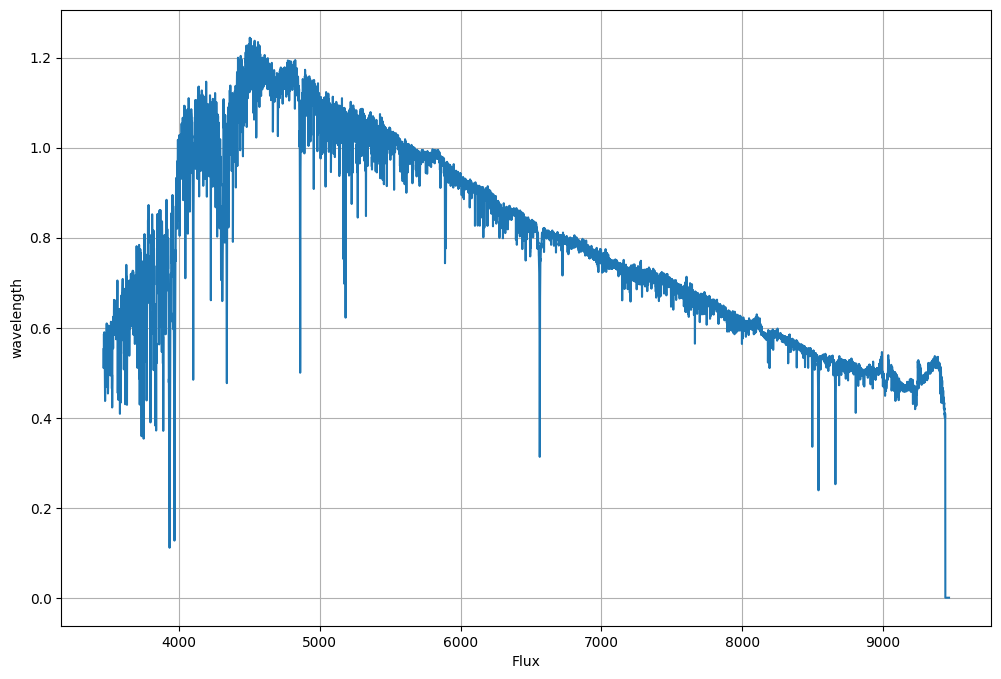

In [71]:
with fits.open(path_249) as data_249:
    hdr = data_249[0].header    # definig the primary HDU header

    crval = hdr["CRVAL1"]      # start value of the wavelength pixel
    cdelt = hdr["CDELT1"]      # step value of the wavelength pixel 

    n_wavelength_points = len(data_249[0].data)    # total number of wavelength points 
    wavelength = crval + cdelt * np.arange(n_wavelength_points)   # defining the wavelength interval(array)
    
    flux = data_249[0].data     # defining the flux array
    

    # plotting
    plt.figure(figsize= (12, 8))
    plt.xlabel("Flux")
    plt.ylabel("wavelength")
    plt.plot(wavelength,flux)
    plt.grid()
    plt.show()